In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import json
from collections import defaultdict
from scipy.spatial.distance import cosine, jensenshannon
from scipy.stats import pearsonr, spearmanr
import math

import matplotlib.pyplot as plt


In [ ]:
def segment_and_average_with_element_padding(arr, n_segments=5):
    """
    Segment a numpy array into n_segments equal parts with element-wise padding.
    Each element is repeated the same number of times to reach minimum length.
    
    Parameters:
    arr: numpy array (non-empty)
    n_segments: number of segments (default 5)
    
    Returns:
    numpy array of exactly n_segments averages
    """
    if len(arr) == 0:
        raise ValueError("Array cannot be empty")
    
    if len(arr) < n_segments:
        # Calculate how many times to repeat each element
        repeat_times = math.ceil(n_segments / len(arr))
        # Repeat each element repeat_times times
        padded_arr = np.repeat(arr, repeat_times) 
    else:
        padded_arr = arr
    
    # Split into segments and calculate averages
    segments = np.array_split(padded_arr, n_segments)
    averages = np.array([segment.mean() for segment in segments])
    
    return averages

In [3]:
all_terminal_nodes = pd.read_csv("data/all_terminal_nodes.txt", header=None).squeeze().tolist()


In [4]:
all_lineage_set = set()
lineage_ts_min = {}
lineage_ts_max = {}
reporter_names = []
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.')[0]
        reporter_names.append(protein_name)
        df = pd.read_csv(os.path.join("data/protein", file))
        lineage_names = set(df['Cell-name'].unique())
        groups = df.groupby('Cell-name')
        for name, group in groups:
            cur_min = group['Time'].min()
            cur_max = group['Time'].max()
            lineage_ts_min[name] = min(lineage_ts_min.get(name, cur_min), cur_min)
            lineage_ts_max[name] = max(lineage_ts_max.get(name, cur_max), cur_max)
        all_lineage_set.update(lineage_names)

100%|██████████| 293/293 [00:28<00:00, 10.42it/s]


In [5]:
lineage_exp_df_dict = {}
for lineage in all_lineage_set:
    df = pd.DataFrame(columns=reporter_names)
    df.index.name = 'Time'
    # fill index as range from min to max
    df = df.reindex(range(lineage_ts_min[lineage], lineage_ts_max[lineage] + 1))
    lineage_exp_df_dict[lineage] = df

In [6]:
all_lineage_list = sorted(list(all_lineage_set))
print(f"Total number of unique lineages: {len(all_lineage_list)}")

Total number of unique lineages: 1335


In [7]:
lineage_exp_df_dict = {}
for lineage in all_lineage_list:
    df = pd.DataFrame(columns=reporter_names)
    # split time into 5 segments
    df.index.name = 'Time Ranges'
    # fill index as range from min to max
    df = df.reindex(range(5))
    lineage_exp_df_dict[lineage] = df

In [ ]:
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.csv')[0]
        tf_name = protein_name.split('_')[0]
        df = pd.read_csv(os.path.join("data/protein", file))
        
        # Set the Time column as index for easier alignment
        df_indexed = df.set_index(['Cell-name', 'Time'])
        
        # For each lineage, update the corresponding dataframe
        for lineage_name in df['Cell-name'].unique():
            if lineage_name in all_lineage_list:
                lineage_data = df_indexed.loc[lineage_name]
                lineage_data = lineage_data.groupby(lineage_data.index)[['Raw-expression', 'Adjustment-expression']].mean()
                lineage_exp_df = lineage_exp_df_dict[lineage_name]
                
                # Update all values at once using index alignment 
                lineage_exp_df[protein_name] = segment_and_average_with_element_padding(lineage_data['Adjustment-expression'].values)



In [9]:
# for all the lineage expression dataframes, only keep columns that don't have missing values
for lineage in all_lineage_list:
    df = lineage_exp_df_dict[lineage]
    df.dropna(axis=1, how='any', inplace=True)
    lineage_exp_df_dict[lineage] = df

In [12]:
def lineage_exp_self_correlation(first_time, last_time=5):
    """"
    plot histogram of the correlation coefficients of all lineages
    given how self-correlated they are over time
    """
    corrs = []
    low_corr_lineages_with_pval = []
    for lineage in all_lineage_list:
        df = lineage_exp_df_dict[lineage]
        if df.shape[1] < 50:
            continue
        if df.shape[0] < last_time:
            continue
        first_time_exp = df.iloc[first_time]
        last_time_exp = df.iloc[last_time - 1]
        corr, p_val = pearsonr(first_time_exp, last_time_exp)
        if corr < 0.5:
            low_corr_lineages_with_pval.append((lineage, p_val))
        corrs.append(corr)
    return corrs, low_corr_lineages_with_pval


From time segment 1 to 5, mean self-correlation: 0.8567831622542833, std: 0.10389121764565087
From time segment 2 to 5, mean self-correlation: 0.8998172026336356, std: 0.08631264639553202
From time segment 3 to 5, mean self-correlation: 0.9287805583683566, std: 0.0732530743296325
From time segment 4 to 5, mean self-correlation: 0.9592110274076432, std: 0.05223286989665808


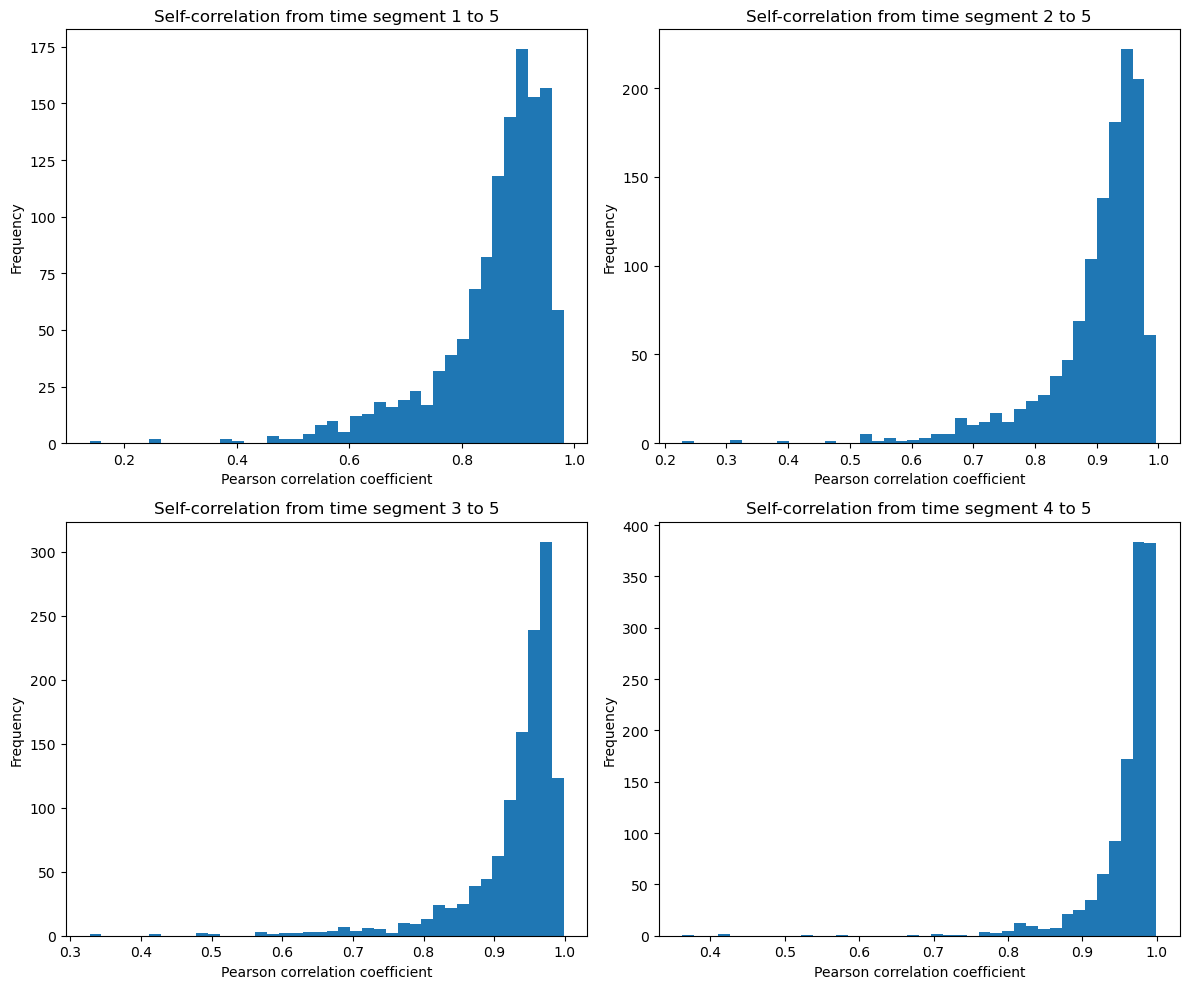

In [13]:
# in a 2 by 2 grid, plot histograms of self-correlation from time segment 1 to 5, 2 to 5, 3 to 5, 4 to 5
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
low_corr_lineages = set()
low_corr_lineages_pval = []

for i in range(4):
    corrs, low_corr_lineages_with_pval = lineage_exp_self_correlation(i, 5)
    for lineage, p_val in low_corr_lineages_with_pval:
        low_corr_lineages.add(lineage)
    print(f"From time segment {i+1} to {5}, mean self-correlation: {np.mean(corrs)}, std: {np.std(corrs)}")
    # plot histogram
    axes[i].hist(corrs, bins=40)
    axes[i].set_title(f"Self-correlation from time segment {i+1} to {5}")
    axes[i].set_xlabel("Pearson correlation coefficient")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:
for lineage in low_corr_lineages:
    print(lineage_ts_min[lineage], lineage_ts_max[lineage], lineage)

134 320 ABplpppapp
1 28 ABa
129 320 Cpaapa
183 320 ABpraaaappa
1 17 P1
239 310 MSppaaaav
136 320 ABprpppapp
191 320 ABplapapppa
1 28 ABp
129 320 Cpaapp
141 320 ABarpaaapp
112 303 MSpaapp
149 320 MSppapaa
173 300 ABprpppapap
1 31 EMS
1 14 AB


4 top layers
5 dead cells
hypoderm: 

In [ ]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
cell_type_df.set_index('wormweb.lineage', inplace=True)
terminal_nodes_with_exp = list(set(all_terminal_nodes) & set(all_lineage_list))
no_type_cells = cell_type_df[cell_type_df["wormweb.type"].isnull()].index.unique().tolist()

In [58]:
for lineage in low_corr_lineages:
    if lineage not in no_type_cells:
        print(lineage)

Cpaapa
MSppaaaav
Cpaapp
ABprpppapap
AB


In [36]:
"ABpraapapppp" in low_corr_lineages

False

In [19]:
max_time = max(lineage_ts_max.values())
max_time

np.int64(320)

In [ ]:
# calculate the sparsity of each lineage
lineage_sparsity = {}
for lineage, df in lineage_exp_df_dict.items():
    total_values = df.size
    non_null_values = df.notnull().sum().sum()
    sparsity = 1 - (non_null_values / total_values)
    lineage_sparsity[lineage] = sparsity

In [ ]:
lineage_raw_expression_mat = []
lineage_adj_expression_mat = []
lineage_tf_st = defaultdict(set)
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.csv')[0]
        tf_name = protein_name.split('_')[0]
        df = pd.read_csv(os.path.join("data/protein", file))
        groups = df.groupby('Cell-name')
        lineage_raw_expression = []
        lineage_adj_expression = []
        for lineage, lineage_df in groups:
            lineage_tf_st[lineage].add(tf_name)
        for name in all_lineage_list:
            if name not in groups.groups:
                lineage_raw_expression.append(np.nan)
                lineage_adj_expression.append(np.nan)
                continue
            lineage_df = groups.get_group(name)
            lineage_raw_expression.append(lineage_df['Raw-expression'].mean())
            lineage_adj_expression.append(lineage_df['Adjustment-expression'].mean())
        lineage_raw_expression_mat.append(lineage_raw_expression)
        lineage_adj_expression_mat.append(lineage_adj_expression)

100%|██████████| 293/293 [01:08<00:00,  4.29it/s]


In [ ]:
reporter_names = []
lineage_raw_expression_mat = []
lineage_adj_expression_mat = []
lineage_tf_st = defaultdict(set)
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.csv')[0]
        tf_name = protein_name.split('_')[0]
        df = pd.read_csv(os.path.join("data/protein", file))
        groups = df.groupby('Cell-name')
        lineage_raw_expression = []
        lineage_adj_expression = []
        reporter_names.append(protein_name)
        for lineage, lineage_df in groups:
            lineage_df.sort_values("Time")
            time_window = lineage_df['Time'].max() - lineage_df['Time'].min()
            if time_window != len(lineage_df) -1 or len(lineage_df["Time"].unique()) != len(lineage_df):
                print(f"Warning: {lineage} with tf {tf_name} is unevenly sampled")

 47%|████▋     | 138/293 [00:32<00:36,  4.28it/s]

100%|██████████| 293/293 [01:08<00:00,  4.28it/s]


In [ ]:
# fill nan with 0
lineage_raw_expression_mat = np.nan_to_num(np.array(lineage_raw_expression_mat), nan=0.0)
lineage_adj_expression_mat = np.nan_to_num(np.array(lineage_adj_expression_mat), nan=0.0)

In [ ]:
# check number of zeros in each column
lineage_raw_expression_zeros = (lineage_raw_expression_mat == 0).sum(axis=0)
lineage_adj_expression_zeros = (lineage_adj_expression_mat == 0).sum(axis=0)

In [ ]:
lineage_raw_expression_df = pd.DataFrame(lineage_raw_expression_mat, columns=all_lineage_list, index=reporter_names)
lineage_adj_expression_df = pd.DataFrame(lineage_adj_expression_mat, columns=all_lineage_list, index=reporter_names)
# lineage_raw_expression_df.to_csv('data/protein/aggregated_all/lineage_raw_expression.csv')
# lineage_adj_expression_df.to_csv('data/protein/aggregated_all/lineage_adj_expression.csv')

In [ ]:
reporter_names = []
binned_lineage_raw_expression_mat = []
binned_lineage_adj_expression_mat = []
lineage_tf_st = defaultdict(set)
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.csv')[0]
        tf_name = protein_name.split('_')[0]
        df = pd.read_csv(os.path.join("data/protein", file))
        groups = df.groupby('Cell-name')
        lineage_raw_expression = []
        lineage_adj_expression = []
        reporter_names.append(protein_name)
        for lineage, lineage_df in groups:
            lineage_tf_st[lineage].add(tf_name)
        for name in all_lineage_list:
            if name not in groups.groups:
                lineage_raw_expression.append(np.nan)
                lineage_adj_expression.append(np.nan)
                continue
            lineage_df = groups.get_group(name)
            if name in all_terminal_nodes:
                if len(lineage_df) > 2:
                    binned_length = math.ceil((len(lineage_df) - 2) / 10)
                    lineage_raw_expression.append(lineage_df.sort_values(by="Time")["Raw-expression"].values[-1-binned_length:-1].mean())
                    lineage_adj_expression.append(lineage_df.sort_values(by="Time")['Adjustment-expression'].values[-1-binned_length:-1].mean())
                else:
                    lineage_raw_expression.append(np.nan)
                    lineage_adj_expression.append(np.nan)
            else:
                if len(lineage_df) > 3:
                    binned_length = math.ceil((len(lineage_df) - 3) / 10)
                    lineage_raw_expression.append(lineage_df.sort_values(by="Time")["Raw-expression"].values[-2-binned_length:-2].mean())
                    lineage_adj_expression.append(lineage_df.sort_values(by="Time")['Adjustment-expression'].values[-2-binned_length:-2].mean())
                else:
                    lineage_raw_expression.append(np.nan)
                    lineage_adj_expression.append(np.nan)
        binned_lineage_raw_expression_mat.append(lineage_raw_expression)
        binned_lineage_adj_expression_mat.append(lineage_adj_expression)

100%|██████████| 293/293 [02:06<00:00,  2.31it/s]


In [ ]:
# fill nan with 0
binned_lineage_raw_expression_mat = np.nan_to_num(np.array(binned_lineage_raw_expression_mat), nan=0.0)
binned_lineage_adj_expression_mat = np.nan_to_num(np.array(binned_lineage_adj_expression_mat), nan=0.0)
binned_lineage_raw_expression_df = pd.DataFrame(binned_lineage_raw_expression_mat, columns=all_lineage_list, index=reporter_names)
binned_lineage_adj_expression_df = pd.DataFrame(binned_lineage_adj_expression_mat, columns=all_lineage_list, index=reporter_names)
# then get rid of the columns that have all zeroes
binned_lineage_raw_expression_df = binned_lineage_raw_expression_df.loc[:, (binned_lineage_raw_expression_df != 0).any(axis=0)]
binned_lineage_adj_expression_df = binned_lineage_adj_expression_df.loc[:, (binned_lineage_adj_expression_df != 0).any(axis=0)]

In [ ]:
binned_lineage_raw_expression_df.to_csv('data/protein/aggregated_all/binned_tenth_lineage_raw_expression.csv')
binned_lineage_adj_expression_df.to_csv('data/protein/aggregated_all/binned_tenth_lineage_adj_expression.csv')

In [ ]:
reporter_names = []
lineage_end_binary_expression_mat = []
lineage_binary_expression_mat = []
lineage_tf_st = defaultdict(set)
state_threshold = 3.2
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.csv')[0]
        tf_name = protein_name.split('_')[0]
        df = pd.read_csv(os.path.join("data/protein", file))
        groups = df.groupby('Cell-name')
        lineage_end_binary_expression = []
        lineage_binary_expression = []
        reporter_names.append(protein_name)
        for lineage, lineage_df in groups:
            lineage_tf_st[lineage].add(tf_name)
        for name in all_lineage_list:
            if name not in groups.groups:
                lineage_end_binary_expression.append(False)
                lineage_binary_expression.append(False)
                continue
            lineage_df = groups.get_group(name)
            if name in all_terminal_nodes:
                if len(lineage_df) > 2:
                    last_val = lineage_df.sort_values(by="Time")["Raw-expression"].values[-1]
                    max_val = lineage_df.sort_values(by="Time")["Raw-expression"].values[2:].max()
                    lineage_end_binary_expression.append(last_val > state_threshold)
                    lineage_binary_expression.append(max_val > state_threshold)
                else:
                    lineage_end_binary_expression.append(False)
                    lineage_binary_expression.append(False)
            else:
                if len(lineage_df) > 3:
                    last_val = lineage_df.sort_values(by="Time")["Raw-expression"].values[-2]
                    max_val = lineage_df.sort_values(by="Time")["Raw-expression"].values[2:-1].max()
                    lineage_end_binary_expression.append(last_val > state_threshold)
                    lineage_binary_expression.append(max_val > state_threshold)
                else:
                    lineage_end_binary_expression.append(False)
                    lineage_binary_expression.append(False)
        lineage_end_binary_expression_mat.append(lineage_end_binary_expression)
        lineage_binary_expression_mat.append(lineage_binary_expression)

100%|██████████| 293/293 [01:57<00:00,  2.49it/s]


In [ ]:
# fill nan with 0
# lineage_end_binary_expression_mat = np.nan_to_num(np.array(lineage_end_binary_expression_mat), nan=False)
# lineage_binary_expression_mat = np.nan_to_num(np.array(lineage_binary_expression_mat), nan=False)
lineage_end_binary_expression_df = pd.DataFrame(lineage_end_binary_expression_mat, columns=all_lineage_list, index=reporter_names)
lineage_binary_expression_df = pd.DataFrame(lineage_binary_expression_mat, columns=all_lineage_list, index=reporter_names)
# then get rid of the columns that have all zeroes
lineage_end_binary_expression_df = lineage_end_binary_expression_df.loc[:, (lineage_end_binary_expression_df != 0).any(axis=0)]
lineage_binary_expression_df = lineage_binary_expression_df.loc[:, (lineage_binary_expression_df != 0).any(axis=0)]

In [ ]:
lineage_end_binary_expression_df.to_csv('data/protein/aggregated_all/lineage_end_binary_expression.csv')
lineage_binary_expression_df.to_csv('data/protein/aggregated_all/lineage_binary_expression.csv')

In [ ]:
reporter_names = []
lineage_first_expression_mat = []
lineage_last_expression_mat = []
lineage_tf_st = defaultdict(set)
state_threshold = 3.2
for file in tqdm(os.listdir("data/protein")):
    if file.endswith(".csv"):
        protein_name = file.split('.csv')[0]
        tf_name = protein_name.split('_')[0]
        df = pd.read_csv(os.path.join("data/protein", file))
        groups = df.groupby('Cell-name')
        lineage_first_expression = []
        lineage_last_expression = []
        reporter_names.append(protein_name)
        for lineage, lineage_df in groups:
            lineage_tf_st[lineage].add(tf_name)
        for name in all_lineage_list:
            if name not in groups.groups:
                lineage_first_expression.append(0)
                lineage_last_expression.append(0)
                continue
            lineage_df = groups.get_group(name)
            if name in all_terminal_nodes:
                if len(lineage_df) > 2:
                    sorted = lineage_df.sort_values(by="Time")
                    first_val = sorted["Raw-expression"].values[2]
                    last_val = sorted["Raw-expression"].values[-1]
                    lineage_first_expression.append(first_val)
                    lineage_last_expression.append(last_val)
                else:
                    lineage_first_expression.append(0)
                    lineage_last_expression.append(0)
            else:
                if len(lineage_df) > 3:
                    sorted = lineage_df.sort_values(by="Time")
                    first_val = sorted["Raw-expression"].values[2]
                    last_val = sorted["Raw-expression"].values[-2]
                    lineage_first_expression.append(first_val)
                    lineage_last_expression.append(last_val)
                else:
                    lineage_first_expression.append(0)
                    lineage_last_expression.append(0)
        lineage_first_expression_mat.append(lineage_first_expression)
        lineage_last_expression_mat.append(lineage_last_expression)

100%|██████████| 293/293 [01:24<00:00,  3.45it/s]


In [ ]:
lineage_first_expression_df = pd.DataFrame(lineage_first_expression_mat, columns=all_lineage_list, index=reporter_names)
lineage_last_expression_df = pd.DataFrame(lineage_last_expression_mat, columns=all_lineage_list, index=reporter_names)
# then get rid of the columns that have all zeroes
lineage_first_expression_df = lineage_first_expression_df.loc[:, (lineage_first_expression_df != 0).any(axis=0)]
lineage_last_expression_df = lineage_last_expression_df.loc[:, (lineage_last_expression_df != 0).any(axis=0)]

In [ ]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did


In [ ]:
from collections import defaultdict
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
spearman_correlation_list = []
pearson_correlation_list = []
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    if parent:
        lookup_name = map_names(node["did"])
        p_lookup_name = map_names(parent['did'])
        if lookup_name in lineage_first_expression_df.columns and p_lookup_name in lineage_last_expression_df.columns:
            # compute correlation
            parent_exp_vector = lineage_last_expression_df[p_lookup_name]
            child_exp_vector = lineage_first_expression_df[lookup_name]
            cor, p_val = spearmanr(parent_exp_vector, child_exp_vector)
            spearman_correlation_list.append(cor)
            cor, p_val = pearsonr(parent_exp_vector, child_exp_vector)
            pearson_correlation_list.append(cor)
    if len(children) == 0:
        lookup_name = map_names(node["did"])
        p_lookup_name = map_names(parent['did'])
        terminal_nodes.append(lookup_name)
        terminal_parents.append(p_lookup_name)
        terminal_parents_dict[p_lookup_name].append(lookup_name)
        terminal_ancestry[len(terminal_nodes)-1] = ancestors
    else:
        for child in children:
            dfs(child, node, ancestors + [node["did"]])

dfs(lineage_data, None)

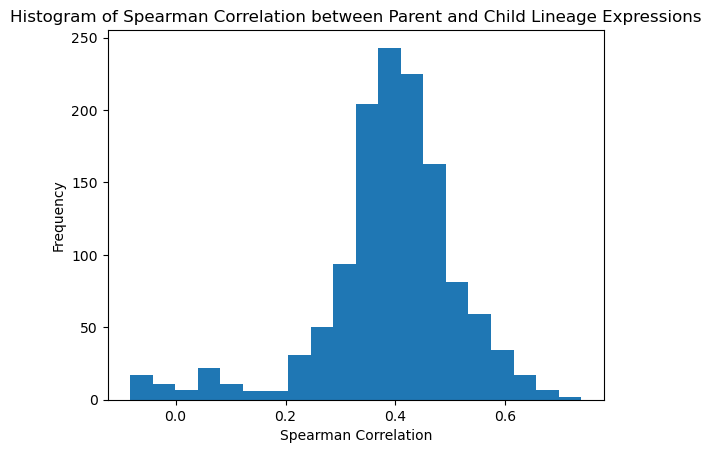

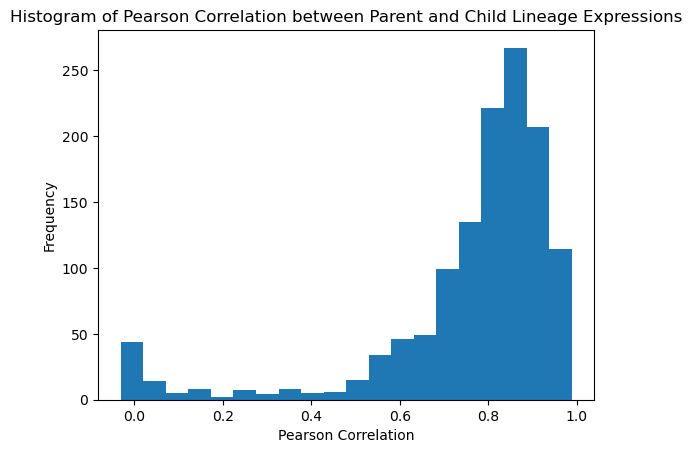

In [ ]:
# plot correlation_list in a histogram
import matplotlib.pyplot as plt
plt.hist([c for c in spearman_correlation_list if not np.isnan(c)], bins=20)
plt.xlabel('Spearman Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Spearman Correlation between Parent and Child Lineage Expressions')
plt.show()

plt.hist([c for c in pearson_correlation_list if not np.isnan(c)], bins=20)
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Pearson Correlation between Parent and Child Lineage Expressions')
plt.show()

In [ ]:
all_tf_names = set()
for i in lineage_adj_expression_df.index:
    all_tf_names.add(i.split('_')[0])

In [ ]:
all_coverage_lineages = []
for lineage, tf_set in lineage_tf_st.items():
    if len(tf_set) == len(all_tf_names):
        all_coverage_lineages.append(lineage)
        

In [ ]:
supplementary_lineage_expression_df = pd.read_csv('data/protein/aggregated_all/s3.csv', index_col=0)
supplementary_lineage_expression_df = supplementary_lineage_expression_df.T
# supplementary_lineage_expression_df.sort_index(inplace=True)

In [ ]:
supplementary_lineage_expression_df.sort_index(inplace=True)
lineage_adj_expression_df.sort_index(inplace=True)
supplementary_lineage_expression_df.head(10)

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
AHR-1_SYS571,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ALR-1_RW10757,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ALR-1_SYS139,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ALY-1_SYS619,0.0,0.00,0.00,33.29,153.49,146.94,182.34,109.03,60.47,77.66,...,65.56,66.30,85.99,42.42,41.02,0.00,0.00,0.00,0.00,0.00
ALY-2_SYS721,NaN,41.32,36.95,24.74,56.10,32.07,38.97,25.17,36.04,32.02,...,48.07,50.92,50.60,45.33,31.37,33.38,36.10,47.72,125.73,122.28
APTF-1_SYS114,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ARID-1_SYS679,0.0,0.00,5.82,10.66,19.79,17.35,19.77,14.66,9.06,9.09,...,7.20,9.31,9.12,5.72,3.34,0.00,0.23,0.85,0.14,0.00
AST-1_SYS1190,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.93,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ATF-7_SYS495,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,2.27,0.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
select_lineage_adj_expression_df = lineage_adj_expression_df[supplementary_lineage_expression_df.columns]
select_lineage_adj_expression_df.head(10)

,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.000000,0.009286,0.000000,0.005909,0.121200,0.241562,0.270526,0.824118,1.030208,0.512222,...,1.004105,0.582737,0.152000,0.314066,0.407253,0.014000,0.062609,0.115000,0.206531,0.184745
AHR-1_SYS571,0.000000,0.000000,0.000000,0.000000,0.008400,0.187879,0.201163,0.423500,0.323158,0.408378,...,0.316282,0.510128,0.150943,0.429863,0.530685,0.000000,0.000000,0.003966,0.017972,0.004764
ALR-1_RW10757,0.000000,0.000000,0.000000,0.014286,0.028333,0.218438,0.223590,0.847361,0.457568,0.848919,...,0.533299,0.188351,0.105870,0.214842,0.134316,0.000000,0.000000,0.065082,0.192586,0.462586
ALR-1_SYS139,0.000000,0.000000,0.035000,0.000000,0.010385,0.446176,0.240000,0.405062,0.056316,0.257895,...,0.300879,0.280110,0.227500,0.430595,0.477381,0.000000,0.055000,0.021406,0.063540,0.025000
ALY-1_SYS619,0.000000,0.000000,1.187333,33.326522,145.158000,140.218125,175.907838,108.982346,60.491111,76.409259,...,67.240278,68.160972,85.057708,44.635652,43.466377,0.000000,0.000000,0.040169,0.019939,0.410848
ALY-2_SYS721,17.206000,37.820833,35.653333,28.266316,54.680000,33.170000,40.205833,27.613803,37.684043,33.918723,...,50.280208,53.104271,51.242553,48.411613,34.004839,36.252000,34.374091,49.302833,127.787143,124.697143
APTF-1_SYS114,0.014286,0.000000,0.000000,0.063043,0.004800,0.042941,0.220256,0.441268,0.699048,0.507619,...,0.526667,0.234127,0.191400,0.175484,0.188710,0.000000,0.000000,0.084154,0.183916,0.190210
ARID-1_SYS679,0.000000,1.180714,8.428667,12.853913,21.350000,19.364118,22.092632,17.604085,12.019375,12.672500,...,10.350690,12.475632,11.678600,8.883012,6.462771,0.268667,3.319167,4.007797,3.345185,3.163704
AST-1_SYS1190,0.000000,0.000000,0.000000,0.005200,0.019655,0.129730,0.309111,0.786667,6.842800,2.871000,...,0.386111,0.130833,0.160000,0.087327,0.016238,0.000000,0.000000,0.075733,0.146578,0.073886
ATF-7_SYS495,0.000000,0.000000,0.055333,0.000000,0.131200,0.286364,0.070000,1.498875,2.304333,2.376333,...,5.313333,3.329773,0.658036,1.551455,1.430211,0.000000,0.029565,0.024483,0.032983,0.025525


In [ ]:
val_mat = select_lineage_adj_expression_df.values
for i in range(val_mat.shape[0]):
    for j in range(val_mat.shape[1]):
        if val_mat[i, j] > 0 and np.isnan(supplementary_lineage_expression_df.iloc[i, j]):
            print(val_mat[i, j], i, j)

In [ ]:
print(supplementary_lineage_expression_df.index[5], supplementary_lineage_expression_df.columns[445])

ALY-2_SYS721 ABp


In [ ]:
supplementary_lineage_expression_df["ABp"]

AHA-1_SYS135     0.0
AHR-1_SYS571     NaN
ALR-1_RW10757    0.0
ALR-1_SYS139     0.0
ALY-1_SYS619     0.0
                ... 
ZIP-8_SYS163     0.0
ZIP-8_SYS454     0.0
ZTF-11_SYS99     0.0
ZTF-30_SYS164    0.0
ZTF-6_SYS464     0.0
Name: ABp, Length: 291, dtype: float64

In [ ]:
select_lineage_adj_expression_df["ABp"]

AHA-1_SYS135     0.000000
AHR-1_SYS571     0.000000
ALR-1_RW10757    0.000000
ALR-1_SYS139     0.000000
ALY-1_SYS619     0.000000
                   ...   
ZIP-8_SYS163     0.000000
ZIP-8_SYS454     0.000000
ZTF-11_SYS99     0.015833
ZTF-30_SYS164    0.000000
ZTF-6_SYS464     0.027143
Name: ABp, Length: 291, dtype: float64

In [ ]:
select_lineage_adj_expression_df["ABalaa"]

AHA-1_SYS135      0.005909
AHR-1_SYS571      0.000000
ALR-1_RW10757     0.014286
ALR-1_SYS139      0.000000
ALY-1_SYS619     33.326522
                   ...    
ZIP-8_SYS163      0.000000
ZIP-8_SYS454      0.025238
ZTF-11_SYS99      0.026957
ZTF-30_SYS164     0.016087
ZTF-6_SYS464      0.000000
Name: ABalaa, Length: 291, dtype: float64

In [ ]:
cosine_similarity = []
for lineage_name in tqdm(supplementary_lineage_expression_df.columns):
    exp_1 = select_lineage_adj_expression_df[lineage_name].values
    exp_2 = supplementary_lineage_expression_df[lineage_name].values
    cosine_similarity.append(1 - cosine(exp_1, exp_2))

100%|██████████| 1204/1204 [00:00<00:00, 69432.19it/s]


In [ ]:
max(cosine_similarity)

np.float64(0.9995882652032434)

In [ ]:
# fill nan with 0 in cosine_similarity
cosine_similarity = np.nan_to_num(cosine_similarity, nan=0.0)
len(cosine_similarity)

1204

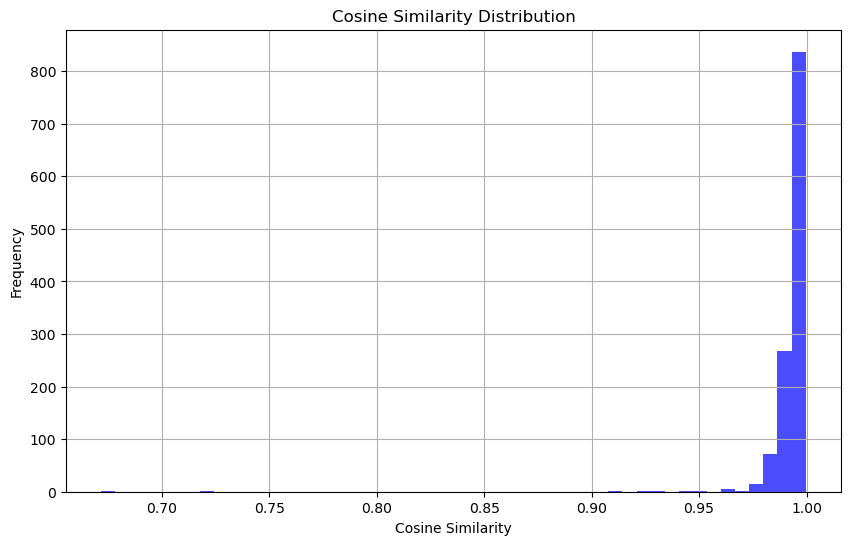

In [ ]:
# plot a histogram of cosine similarity
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(cosine_similarity, bins=50, color='blue', alpha=0.7)
plt.title('Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [ ]:
tf_reporter_list = defaultdict(list)
for protein_name in reporter_names:
    tf_name = protein_name.split('_')[0]
    tf_reporter_list[tf_name].append(protein_name)
    

In [ ]:
for tf_name, reporters in tf_reporter_list.items():
    if len(reporters) == 2:
        exp_1 = supplementary_lineage_expression_df.loc[reporters[0]].values
        exp_2 = supplementary_lineage_expression_df.loc[reporters[1]].values
        # calculate the linear correlation of exp_1 and exp_2
        r, p = pearsonr(exp_1, exp_2)
        print(f"TF: {tf_name}, Correlation: {r:.4f}, p-value: {p:.4e}")


TF: TBX-9, Correlation: 0.7697, p-value: 1.6083e-236
TF: EOR-1, Correlation: 0.7282, p-value: 1.8590e-199
TF: LIM-6, Correlation: 0.9984, p-value: 0.0000e+00
TF: SYD-9, Correlation: nan, p-value: nan
TF: CEH-20, Correlation: 0.8723, p-value: 0.0000e+00
TF: ELT-1, Correlation: 0.9120, p-value: 0.0000e+00
TF: CEH-31, Correlation: 0.6289, p-value: 1.5112e-133
TF: SKN-1, Correlation: nan, p-value: nan
TF: ALR-1, Correlation: 0.8415, p-value: 9.8813e-324
TF: SEM-2, Correlation: 0.8208, p-value: 1.2082e-294
TF: LIN-39, Correlation: 0.9168, p-value: 0.0000e+00
TF: T18D3.7, Correlation: nan, p-value: nan
TF: KLF-3, Correlation: nan, p-value: nan
TF: CEH-23, Correlation: nan, p-value: nan
TF: MED-1, Correlation: nan, p-value: nan
TF: UNC-3, Correlation: 0.6956, p-value: 7.6155e-175
TF: ELT-2, Correlation: 0.9539, p-value: 0.0000e+00
TF: UNC-30, Correlation: 0.4235, p-value: 1.3472e-53
TF: FKH-3, Correlation: nan, p-value: nan
TF: EGL-5, Correlation: 0.8310, p-value: 1.9332e-308
TF: CND-1, Corre

/tmp/ipykernel_1866301/1370482265.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(exp_1, exp_2)


In [ ]:
for tf_name, reporters in tf_reporter_list.items():
    if len(reporters) == 2:
        exp_1 = select_lineage_adj_expression_df.loc[reporters[0]].values
        exp_2 = select_lineage_adj_expression_df.loc[reporters[1]].values
        # calculate the linear correlation of exp_1 and exp_2
        r, p = pearsonr(exp_1, exp_2)
        print(f"TF: {tf_name}, Correlation: {r:.4f}, p-value: {p:.4e}")


TF: TBX-9, Correlation: 0.8540, p-value: 0.0000e+00
TF: EOR-1, Correlation: 0.7789, p-value: 8.3570e-246
TF: LIM-6, Correlation: 0.9136, p-value: 0.0000e+00
TF: SYD-9, Correlation: 0.5278, p-value: 2.6169e-87
TF: CEH-20, Correlation: 0.8979, p-value: 0.0000e+00
TF: ELT-1, Correlation: 0.9272, p-value: 0.0000e+00
TF: CEH-31, Correlation: 0.7511, p-value: 5.5863e-219
TF: SKN-1, Correlation: 0.3285, p-value: 1.0777e-31
TF: ALR-1, Correlation: 0.8638, p-value: 0.0000e+00
TF: SEM-2, Correlation: 0.8814, p-value: 0.0000e+00
TF: LIN-39, Correlation: 0.9237, p-value: 0.0000e+00
TF: T18D3.7, Correlation: 0.6082, p-value: 1.0371e-122
TF: KLF-3, Correlation: 0.0578, p-value: 4.5091e-02
TF: CEH-23, Correlation: 0.6138, p-value: 1.3986e-125
TF: MED-1, Correlation: 0.1401, p-value: 1.0671e-06
TF: UNC-3, Correlation: 0.7856, p-value: 6.9772e-253
TF: ELT-2, Correlation: 0.9584, p-value: 0.0000e+00
TF: UNC-30, Correlation: 0.6717, p-value: 8.6753e-159
TF: FKH-3, Correlation: 0.5083, p-value: 4.3817e-80

In [ ]:
np.corrcoef(exp_1, exp_2)

array([[1.        , 0.64013242],
       [0.64013242, 1.        ]])

In [ ]:
len(set(lineage_adj_expression_df.columns).intersection(set(supplementary_lineage_expression_df.columns)))

1204

In [ ]:
for name, df in groups:
    print(df)
    break

0    ABa
Name: Cell-name, dtype: object


In [ ]:
lineage_raw_expression_df = pd.read_csv('data/protein/aggregated_all/lineage_raw_expression.csv', index_col=0)
lineage_adj_expression_df = pd.read_csv('data/protein/aggregated_all/lineage_adj_expression.csv', index_col=0)


In [ ]:
# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

    
def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')

terminal_nodes = []
terminal_parents = []
internal_nodes = []
terminal_graph = defaultdict(list)
def dfs(node, parent):
    children = node.get("children", [])
    if len(children) == 0:
        lookup_name = map_names(node["did"])
        p_lookup_name = map_names(parent['did'])
        terminal_nodes.append(lookup_name)
        terminal_parents.append(p_lookup_name)
        terminal_graph[p_lookup_name].append(lookup_name)
    else:
        lookup_name = map_names(node["did"])
        internal_nodes.append(lookup_name)
        for child in children:
            dfs(child, node)

dfs(lineage_data, None)

In [ ]:
len(internal_nodes), len(terminal_nodes), len(terminal_parents)

(1091, 1092, 1092)

In [ ]:
len(set(terminal_nodes).intersection(set(lineage_adj_expression_df.columns)))

600

In [ ]:
len(set(internal_nodes).intersection(set(lineage_adj_expression_df.columns)))

721

In [ ]:
set(lineage_adj_expression_df.columns).difference(set(terminal_nodes).union(set(internal_nodes)))

{'ABalaappaaa',
 'ABalaappaap',
 'ABalapapaaa',
 'ABalapapaap',
 'ABplaaapapa',
 'ABplaaapapp',
 'ABplpaappaaa',
 'ABplpaappaap',
 'ABprppaaapa',
 'ABprppaaapp',
 'ABprpppppapa',
 'ABprpppppapp',
 'Dpappa',
 'Dpappp'}

In [ ]:
lineage_adj_expression_df.shape

(291, 1335)